# TP2 - Etapa 1 en Google Colab: dataset, preprocesamiento, entrenamiento y comparacion de modelos

Notebook de trabajo de la Etapa 1: analisis del dataset, preprocesamiento, carga de base de datos vectorial

El entrenamiento se realiza en Colab para aprovechar la GPU:
**Entorno de ejecucion -> Cambiar tipo de entorno de ejecucion -> GPU (T4)**.

**Aclaración metodológica**

Las funciones implementadas en este notebook corresponden a una adaptación del pipeline originalmente encapsulado en la clase SimilarityService.
Esta adaptación se realizó con fines ilustrativos, permitiendo visualizar de forma clara el flujo completo del sistema.

Asimismo, la estructura de embeddings.json se utiliza como representación conceptual de la base vectorial, la cual en la implementación final se encuentra desplegada mediante pgvector en una base de datos relacional optimizada para búsqueda de similitud.


**Objetivo: Implementar:**

● extract_embedding(image)

● search_similar_images(embedding, top_k)

● predict_breed_from_neighbors(results)



## Equipo
- Alumno 1 : Almada Manuela
- Alumno 2 : Sanz Alfredo

## 1. Clonar el repositorio

Si tu fork es privado, genera un token de acceso (GitHub -> Settings -> Developer settings ->
Personal access tokens) y usalo en la URL, o sube un zip del proyecto a Colab/Drive.

In [ ]:
# TO-DO: completar con la URL de tu fork.
# Repo privado: https://<TOKEN>@github.com/<usuario>/tuia-dog-recognition-app.git
REPO_URL = "https://github.com/manuela-almada/tuia-dog-recognition-app.git"

!git clone $REPO_URL proyecto

Cloning into 'proyecto'...
remote: Enumerating objects: 209, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 209 (delta 30), reused 22 (delta 22), pack-reused 171 (from 1)
Receiving objects: 100% (209/209), 13.15 MiB | 29.60 MiB/s, done.
Resolving deltas: 100% (88/88), done.


In [ ]:
%cd proyecto
!ls

/content/proyecto/proyecto
data		    Dockerfile.frontend  models     requirements.txt  TP2.pdf
docker-compose.yml  etapa2_colab.ipynb	 output     scripts
Dockerfile	    informe.ipynb	 README.md  src


## 2. Instalar dependencias

Colab ya incluye torch, torchvision, opencv, numpy, scikit-learn y matplotlib;
solo se instala lo que falta.

In [ ]:
!pip install -q pydantic-settings python-dotenv kagglehub albumentations

## 3. Descargar el dataset

In [ ]:
import albumentations
import kagglehub
from pydantic_settings import BaseSettings

print("OK")

OK


In [ ]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from lib.config import settings

import torch
print("dataset_path:", settings.dataset_path)
print("GPU disponible:", torch.cuda.is_available())

dataset_path: data/dataset
GPU disponible: True


In [ ]:
from __future__ import annotations
from email.mime import image

#------------------------------------------------------------------
import torch
from torch import nn
from torchvision.models import resnet18, ResNet18_Weights
#------------------------------------------------------------------

import json
import logging
from pathlib import Path
from typing import Callable, Optional
from uuid import uuid4

import cv2
import numpy as np

from lib.schemas import EmbeddingRecord, Neighbor, SearchResult
from lib.storage.base import EmbeddingStoreProtocol

logger = logging.getLogger(__name__)

print("Imports OK")

Imports OK


In [ ]:
!python scripts/download_dataset.py
!ls data/dataset

Descargando gpiosenka/70-dog-breedsimage-data-set ...
Using Colab cache for faster access to the '70-dog-breedsimage-data-set' dataset.
Dataset disponible en /content/proyecto/proyecto/data/dataset
dogs.csv  test	train  valid


## 4. Analisis del dataset

TO-DO:
- Analizar la distribucion de clases y documentar la cantidad de imagenes por raza.
- Definir los conjuntos de entrenamiento, validacion y prueba.
- Filtrar imagenes de baja calidad (documentar el criterio).

### Análisis del dataset completo

In [ ]:
import pandas as pd

dogs_csv = pd.read_csv('./data/dataset/dogs.csv')
dogs_csv['labels'] = dogs_csv['labels'].str.strip().str.replace(r'\s+', ' ', regex=True)

img_x_raza = dogs_csv['labels'].value_counts()

print(f"Cantidad de imágenes: {len(dogs_csv)}")
print(f"Cantidad de razas: {len(img_x_raza)}")
print(f"Cantidad mínima de imágenes por raza: {img_x_raza.min()}")
print(f"Cantidad máxima de imágenes por raza: {img_x_raza.max()}")
print(f"Cantidad promedio de imágenes por raza: {img_x_raza.mean()}")
print(f"Desviación estándar de imágenes por raza: {img_x_raza.std()}")

Cantidad de imágenes: 9346
Cantidad de razas: 70
Cantidad mínima de imágenes por raza: 85
Cantidad máxima de imágenes por raza: 218
Cantidad promedio de imágenes por raza: 133.5142857142857
Desviación estándar de imágenes por raza: 24.68335286995451


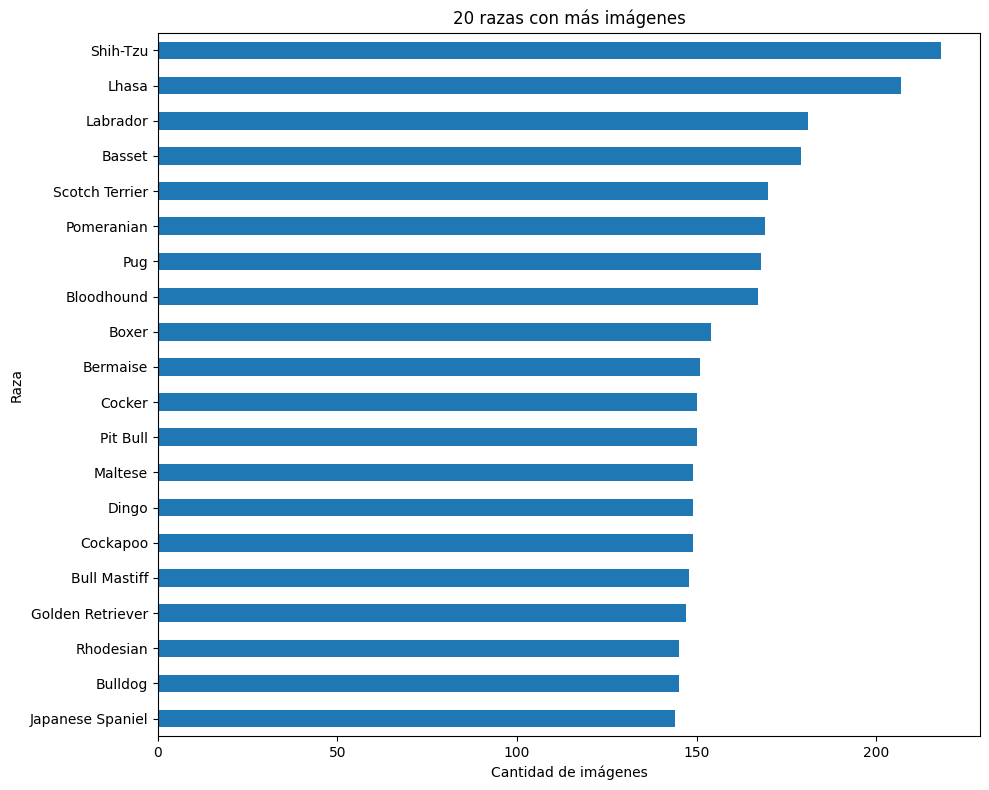

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

img_x_raza.head(20).sort_values().plot(kind="barh")

plt.title("20 razas con más imágenes")
plt.xlabel("Cantidad de imágenes")
plt.ylabel("Raza")
plt.tight_layout()
plt.show()

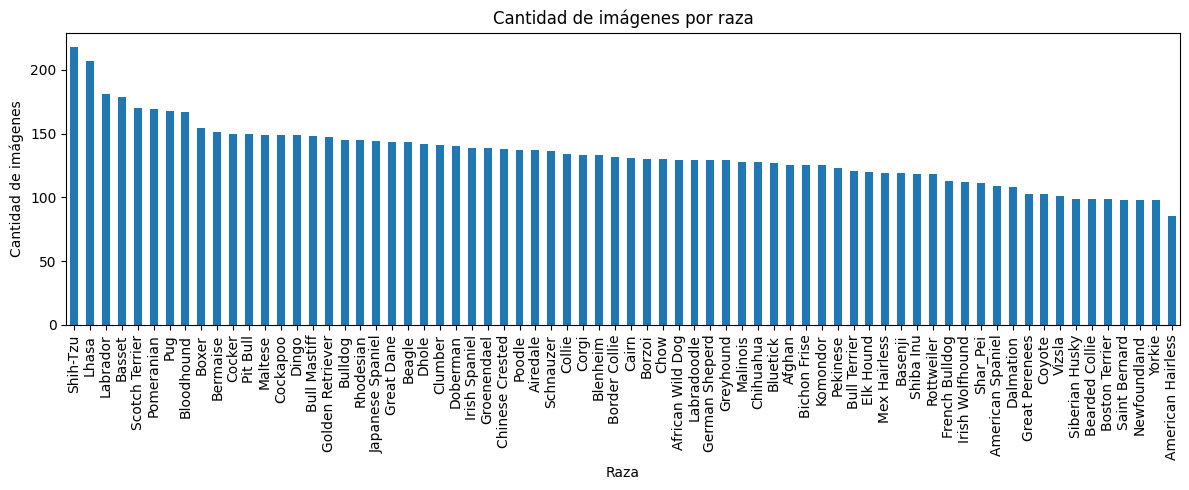

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
img_x_raza.sort_values(ascending=False).plot(kind='bar')
plt.title('Cantidad de imágenes por raza')
plt.xlabel('Raza')
plt.ylabel('Cantidad de imágenes')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Partimos de un dataset compuesto por 9346 imágenes, distribuídas en un total de 70 razas de perros (sin considerar aún la partición en conjuntos de entrenamiento, validación y testeo). La cantidad de imágenes por raza varía entre 85 y 218, con un promedio aproximado de 133 imágenes por clase.

Por otro lado, el desvío estándar es de 24,68 imágenes, lo que indica una dispersión moderada en la distribución de ejemplos entre las distintas razas. Esto sugiere que, el dataset no presenta un desbalance extremo


### Entrenamiento, validación y prueba

In [ ]:
print(dogs_csv['data set'].unique())

['train' 'test' 'valid']


In [ ]:
train_df= dogs_csv[dogs_csv['data set']=='train'].copy()
val_df= dogs_csv[dogs_csv['data set']=='valid'].copy()
test_df= dogs_csv[dogs_csv['data set']=='test'].copy()

print('Split de conjuntos predefinido:')
print(f"Cantidad de imágenes de entrenamiento: {len(train_df)}")
print(f"Cantidad de imágenes de validación: {len(val_df)}")
print(f"Cantidad de imágenes de prueba: {len(test_df)}")

Split de conjuntos predefinido:
Cantidad de imágenes de entrenamiento: 7946
Cantidad de imágenes de validación: 700
Cantidad de imágenes de prueba: 700


In [ ]:
razas_train = set(train_df['labels'])
razas_val = set(val_df['labels'])
razas_test = set(test_df['labels'])

print("Cantidad de razas en Train:", len(razas_train))
print("Cantidad de razas en Val:", len(razas_val))
print("Cantidad de razas en Test:", len(razas_test),)

print("Verificamos si todas las razas están presentes en todos los conjuntos")
print("Train pero no Val:", razas_train - razas_val)
print("Train pero no Test:", razas_train - razas_test)
print("Val pero no Train:", razas_val - razas_train)
print("Test pero no Train:", razas_test - razas_train)

Cantidad de razas en Train: 70
Cantidad de razas en Val: 70
Cantidad de razas en Test: 70
Verificamos si todas las razas están presentes en todos los conjuntos
Train pero no Val: set()
Train pero no Test: set()
Val pero no Train: set()
Test pero no Train: set()


Considerando la partición predeterminada definida en dogs.csv, observamos que la mayor parte de las imágenes se encuentra en el conjunto de entrenamiento (7.946 imágenes). Por su parte, los conjuntos de validación y prueba contienen una cantidad significativamente menor de ejemplos, con 700 imágenes cada uno.

Asimismo, se verificó que las 70 razas del dataset están representadas en los tres conjuntos (train, validation y test). Esto garantiza que todas las clases estarán presentes tanto durante el entrenamiento como en las etapas de validación y evaluación, permitiendo analizar el desempeño del modelo sobre la totalidad de las razas incluidas en el dataset.

Cantidad mínima de imágenes por raza en Train: 65
Cantidad máxima de imágenes por raza en Train: 198
Ratio entre mínimo y máximo de imágenes por raza en Train: 3.046153846153846
Media de imágenes por raza en Train: 113.51428571428572
Desviación estándar de imágenes por raza en Train: 24.683352869954515
Coeficiente de variación de imágenes por raza en Train: 0.21744710557473143


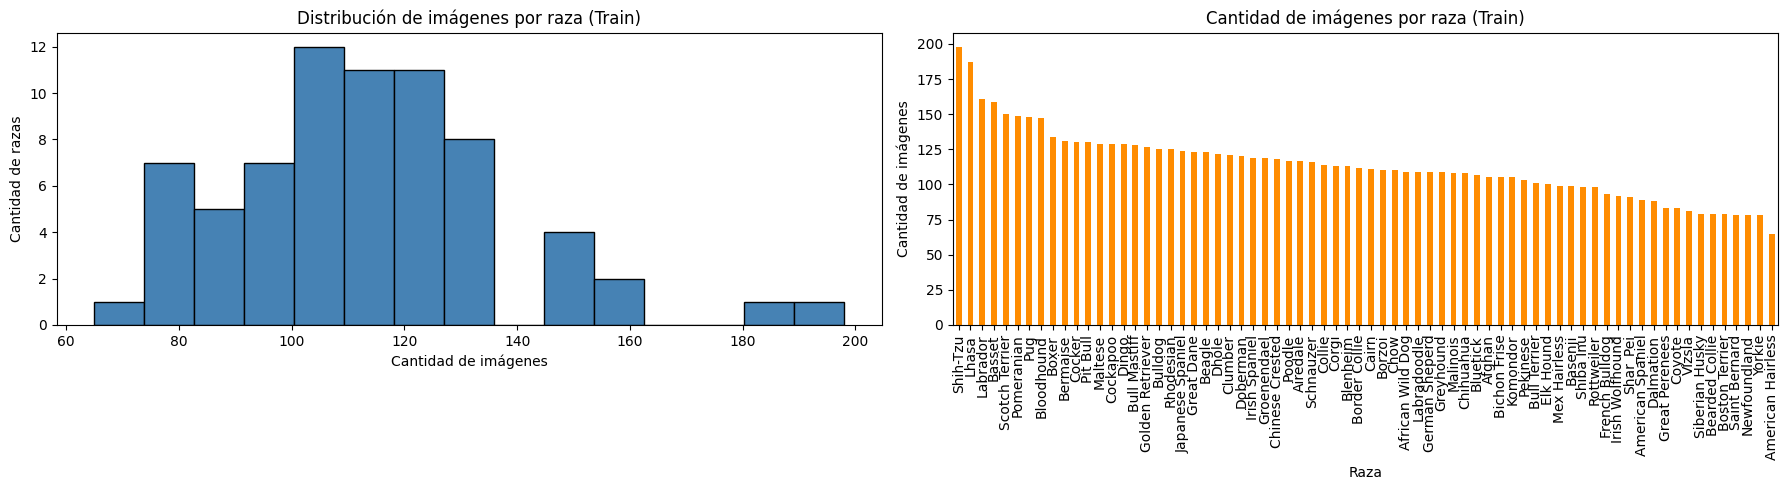

In [ ]:
img_x_raza_train = train_df['labels'].value_counts()

max_train = img_x_raza_train.max()
min_train = img_x_raza_train.min()

ratio_min_max_train = max_train / min_train

media_train= img_x_raza_train.mean()
desvio_train = img_x_raza_train.std()

cv_train = desvio_train/ media_train

print(f"Cantidad mínima de imágenes por raza en Train: {min_train}")
print(f"Cantidad máxima de imágenes por raza en Train: {max_train}")
print(f"Ratio entre mínimo y máximo de imágenes por raza en Train: {ratio_min_max_train}")
print(f"Media de imágenes por raza en Train: {media_train}")
print(f"Desviación estándar de imágenes por raza en Train: {desvio_train}")
print(f"Coeficiente de variación de imágenes por raza en Train: {cv_train}")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Histograma
axes[0].hist(
    img_x_raza_train.values,
    bins=15,
    color='steelblue',
    edgecolor='black'
)

axes[0].set_title("Distribución de imágenes por raza (Train)")
axes[0].set_xlabel("Cantidad de imágenes")
axes[0].set_ylabel("Cantidad de razas")

# Barras
img_x_raza_train.sort_values(ascending=False).plot(
    kind='bar',
    ax=axes[1],
    color='darkorange'
)

axes[1].set_title("Cantidad de imágenes por raza (Train)")
axes[1].set_xlabel("Raza")
axes[1].set_ylabel("Cantidad de imágenes")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

El conjunto de entrenamiento merece un análisis particular, ya que constituye la base sobre la cual el modelo aprenderá las representaciones de las distintas razas. En nuestro caso, además, estas imágenes serán utilizadas para generar los embeddings que conformarán la base de datos vectorial, por lo que la calidad y representatividad de este conjunto tendrán un impacto directo en el desempeño de las búsquedas por similitud.

A partir de las métricas calculadas, observamos que el conjunto presenta un desbalance moderado entre clases. La cantidad de imágenes por raza varía entre 65 y 198 ejemplos, con un coeficiente de variación de 0,21, y un ratio entre max y min que nos informa que la clase con mayor cantidad de elementos tiene aproximadamente 3.4 veces más imágenes que la clase minoritaria. Si bien existen diferencias en la representación de las distintas razas, estas no resultan extremas y sugieren una distribución relativamente homogénea.

Esta observación se ve respaldada por las visualizaciones obtenidas. El histograma muestra que la mayor concentración de clases se encuentra en torno al valor medio (aproximadamente 130 imágenes por raza), aunque también se identifican otros grupos de frecuencias que evidencian cierta heterogeneidad en la distribución. Por su parte, el gráfico de barras permite apreciar las diferencias en la cantidad de muestras disponibles para cada clase, confirmando que algunas razas cuentan con una representación significativamente mayor que otras.

El estudio del balance de clases resulta fundamental, ya que una distribución desigual puede favorecer el aprendizaje de las clases más representadas y dificultar la correcta identificación de aquellas con menor cantidad de ejemplos. Sin emargo teniendo en cuenta el "tamaño" del desbalance, se optó únicamente por monitoriar métricas representativas en este tipo de datasets (como lo es F1-score).


### ¿Qué imagenes filtramos? ¿Con qué criterio?

Integridad del dataset.

Aquellas imágenes que no puedan abrirse correctamente no serán utilizadas en este proceso ya que no será posible acceder a la información presente en las mismas.

In [ ]:
from PIL import Image
from pathlib import Path

image_dir = Path("./data/dataset")

imagenes_corruptas = []
total_imagenes = 0

for img_path in image_dir.rglob("*"):

    if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
        continue

    total_imagenes += 1

    try:
        with Image.open(img_path) as img:
            img.verify()

    except Exception:
        imagenes_corruptas.append(str(img_path))

print(f"Total de imágenes: {total_imagenes}")
print(f"Imágenes corruptas: {len(imagenes_corruptas)}")



Total de imágenes: 9346
Imágenes corruptas: 0


El resto de las imágenes se mantuvo dentro del dataset, ya que se consideró que aplicar filtros basados en tamaño, iluminación u otros aspectos visuales no resultaba conveniente para el objetivo del trabajo. Mantenerlas permite conservar la diversidad natural de los datos, lo cual contribuye a un espacio  más robusto y representativo del dataset.

## Elección del modelo

Para la Etapa 1 se seleccionó ResNet18 preentrenada sobre ImageNet como modelo base para la extracción de embeddings. Esta elección respondió tanto a criterios de desempeño como a restricciones propias de la arquitectura del sistema.

Por un lado, ResNet18 ofrece un excelente equilibrio entre capacidad de representación y costo computacional. Al haber sido entrenada previamente sobre ImageNet, el modelo es capaz de reutilizar características visuales generales —como bordes, texturas, formas y patrones— que resultan altamente transferibles al problema de clasificación y búsqueda por similitud de razas de perros. Esto permite obtener representaciones de alta calidad sin necesidad de entrenar una red desde cero, reduciendo además el riesgo de sobreajuste al trabajar con un dataset de tamaño moderado.

Por otro lado, la elección de ResNet18 estuvo condicionada por la infraestructura utilizada para la base vectorial. El sistema emplea una dimensión fija de 512 para almacenar los embeddings (EMBEDDING_DIM = 512), valor que coincide exactamente con la salida de la penúltima capa de ResNet18 al eliminar su capa de clasificación (fully connected). Esta compatibilidad permitió integrar el modelo directamente con la base vectorial sin realizar transformaciones adicionales sobre los vectores generados.

En consecuencia, la decisión de utilizar ResNet18 en lugar de arquitecturas más profundas, como ResNet50, no respondió únicamente a una cuestión de rendimiento, sino también a la necesidad de mantener la compatibilidad con la configuración del sistema y la infraestructura de almacenamiento de embeddings.

### Preprocesamiento de imágenes

Las imágenes fueron redimensionadas a 224×224 píxeles para adaptarse a los requisitos de entrada del modelo ResNet18.
Además, se aplicó normalización utilizando las estadísticas de ImageNet (media y desvío estándar), dado que el modelo fue preentrenado sobre dicho dataset.

Este procedimiento asegura consistencia entre el dominio de entrenamiento original del modelo y el dominio del problema actual.

In [ ]:
weights = ResNet18_Weights.IMAGENET1K_V1

model = resnet18(weights=weights)
model.fc = nn.Identity()
model.eval()

mean = np.array([0.485,0.456,0.406], dtype=np.float32)
std  = np.array([0.229,0.224,0.225], dtype=np.float32)

def extract_embedding(image_bgr):
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    rgb = cv2.resize(rgb, (224,224))

    arr = rgb.astype(np.float32)/255.
    arr = (arr-mean)/std

    tensor = (
        torch.from_numpy(arr)
        .permute(2,0,1)
        .unsqueeze(0)
        .contiguous()
    )

    with torch.no_grad():
        emb = model(tensor)

    return emb.squeeze().numpy().astype(np.float32)

## Construcción de la base vectorial

La base de embeddings se construyó a partir del conjunto de entrenamiento.
Para cada imagen se generó un vector de características mediante una red neuronal preentrenada, almacenando junto al embedding información asociada como la ruta de la imagen, la clase (breed) y metadatos adicionales.

Este proceso permite representar cada imagen en un espacio vectorial donde la similitud semántica se modela mediante distancia entre embeddings.

In [ ]:
import json
from uuid import uuid4
from tqdm import tqdm
import os

BASE_PATH = "data/dataset"

dogs = pd.read_csv("data/dataset/dogs.csv")

train = dogs[dogs["data set"]=="train"] #solo usamos train para crear la base de datos

database = []

for _, row in tqdm(train.iterrows(), total=len(train)):

    image_path = os.path.join(BASE_PATH, row["filepaths"])

    image = cv2.imread(image_path)

    if image is None:
        print(f"No se pudo leer {image_path}")
        continue

    embedding = extract_embedding(image)

    database.append({
        "id_imagen": str(uuid4()),
        "embedding": embedding.tolist(),
        "path": image_path,
        "breed": row["labels"],
        "metadata": {}
    })


with open("embeddings.json","w") as f:
    json.dump(database, f)
    print(f"Guardamos {len(database)} embeddings en embeddings.json")


100%|██████████| 7946/7946 [08:36<00:00, 15.39it/s]


Guardamos 7946 embeddings en embeddings.json


In [ ]:
# ------------------------------------------------------------------
# Helpers de similitud provistos
# ------------------------------------------------------------------
"""
Métricas de similitud

Para la comparación entre embeddings se utilizaron dos métricas principales:

Similitud coseno
Similitud basada en distancia L2 normalizada

Estas métricas permiten cuantificar la cercanía entre representaciones vectoriales en el espacio de embeddings.
"""
def _cosine(a: np.ndarray, b: np.ndarray) -> float:
        denom = np.linalg.norm(a) * np.linalg.norm(b)
        if denom == 0:
            return 0.0
        return float(np.dot(a, b) / denom)

def _l2_similarity(a: np.ndarray, b: np.ndarray) -> float:
        dist = float(np.linalg.norm(a - b))
        return 1.0 / (1.0 + dist)


## Búsqueda por similitud

Dada una imagen de consulta, se calculan las similitudes con todos los elementos de la base vectorial.
Luego se seleccionan los k vecinos más cercanos, ordenados de mayor a menor similitud.

Este enfoque permite realizar recuperación de imágenes basada en contenid

In [ ]:
def search_similar_images(query_embedding, database, top_k=10):

    neighbors = []

    for record in database:

        score = _cosine(
            np.asarray(query_embedding, dtype=np.float32),
            np.asarray(record["embedding"], dtype=np.float32)
        )

        neighbors.append({
            "path": record["path"],
            "breed": record["breed"],
            "score": score
        })

    neighbors.sort(key=lambda x: x["score"], reverse=True)

    return neighbors[:top_k]

## Predicción de clase

La predicción de la clase se realiza mediante un esquema de votación ponderada por similitud entre los vecinos más cercanos.
Cada vecino aporta evidencia proporcional a su score de similitud.

Si la mejor coincidencia no supera un umbral mínimo, la imagen se clasifica como “unknown”.

In [ ]:
def predict_breed_from_neighbors(results, similarity_threshold=0.55): #CAMBIAR EL UMBRAL DE CONFIANZAAAAA

    if len(results) == 0:
        return "unknown", 0

    best_score = results[0]["score"]

    if best_score < similarity_threshold:
        return "unknown", best_score

    votes = {}

    for neighbor in results:

        breed = neighbor["breed"]

        votes[breed] = votes.get(breed, 0) + neighbor["score"]

    predicted = max(votes, key=votes.get)

    score = max(
        n["score"]
        for n in results
        if n["breed"] == predicted
    )

    return predicted, score

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ndcg_score

y_true = []
y_pred = []
ndcgs = []
BASE_PATH = "data/dataset"

test = dogs[dogs["data set"]=="test"]

for _, row in tqdm(test.iterrows(), total=len(test)):

    image_path = os.path.join(BASE_PATH, row["filepaths"])

    image = cv2.imread(image_path)

    if image is None:
        print(f"No se pudo leer {image_path}")
        continue

    embedding = extract_embedding(image)

    neighbors = search_similar_images(
        embedding,
        database,
        top_k=10
    )

    pred, score = predict_breed_from_neighbors(neighbors)

    y_true.append(row["labels"])
    y_pred.append(pred)
    # NDCG@10
    true_relevance = [
        1 if n["breed"] == row["labels"] else 0
        for n in neighbors
    ]

    pred_scores = [
        n["score"]
        for n in neighbors
    ]

    ndcgs.append(
        ndcg_score([true_relevance], [pred_scores], k=10)
    )


100%|██████████| 700/700 [04:20<00:00,  2.69it/s]


## Resultados finales del modelo

Las métricas obtenidas evidencian un rendimiento elevado del sistema en el conjunto de evaluación:
- ¿Recupera bien? → NDCG.
- ¿Clasifica bien usando esos vecinos? → Accuracy, Precision, Recall y F1.

Accuracy: 0.9386

Precision: 0.9438

Recall: 0.9386

F1-score: 0.9370

NDCG@10: 0.9538

Se observa que todas las métricas superan el 90%, lo que indica un alto nivel de desempeño general del modelo.

Si bien el accuracy puede no ser la métrica más representativa en escenarios potencialmente desbalanceados, el F1-score (0.9370) proporciona una visión más robusta del rendimiento, ya que integra tanto precision como recall, reflejando un equilibrio adecuado entre ambas.

El valor de NDCG@10 = 0.9538, cercano a 1, indica una alta calidad en el ordenamiento de los resultados recuperados.

Esta métrica evalúa qué tan bien el sistema ordena los vecinos más relevantes dentro de las primeras posiciones (top-10), penalizando aquellos casos donde los resultados relevantes aparecen en posiciones más bajas.

En este sentido, el modelo demuestra una capacidad muy sólida para recuperar y priorizar correctamente los ejemplos más similares dentro del espacio vectorial.

En conjunto, los resultados evidencian que el sistema no solo presenta una alta capacidad de clasificación, sino también un excelente desempeño en tareas de recuperación por similitud, lo que confirma la efectividad del enfoque basado en embeddings.

In [ ]:
#Métricas
#Por desbalance usamos average="macro". Así cada raza pesa lo mismo, independientemente de cuántas imágenes tenga.
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
mean_ndcg = np.mean(ndcgs) #Tomamos el promedio ya que tenemos más de una raza en test

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"NDCG@10  : {mean_ndcg:.4f}")

Accuracy : 0.9386
Precision: 0.9438
Recall   : 0.9386
F1 Score : 0.9370
NDCG@10  : 0.9538


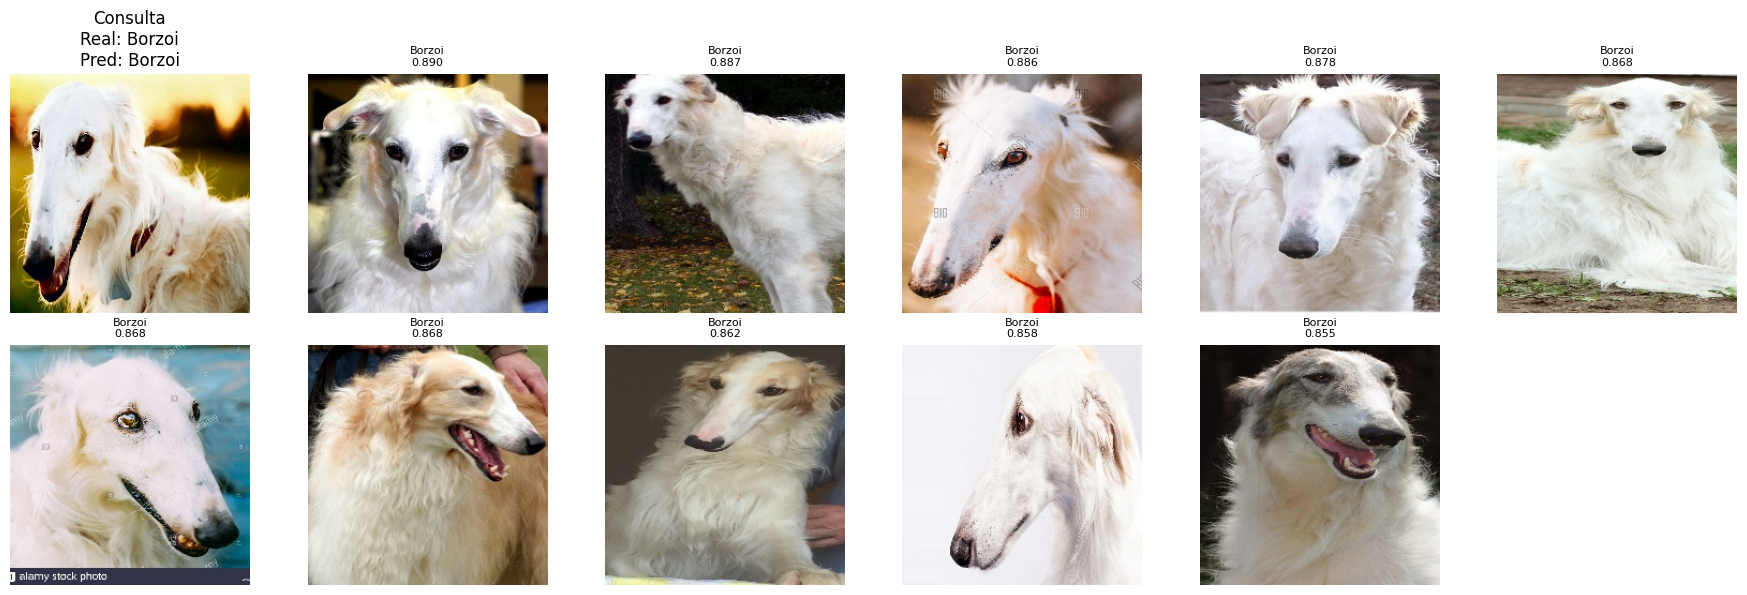

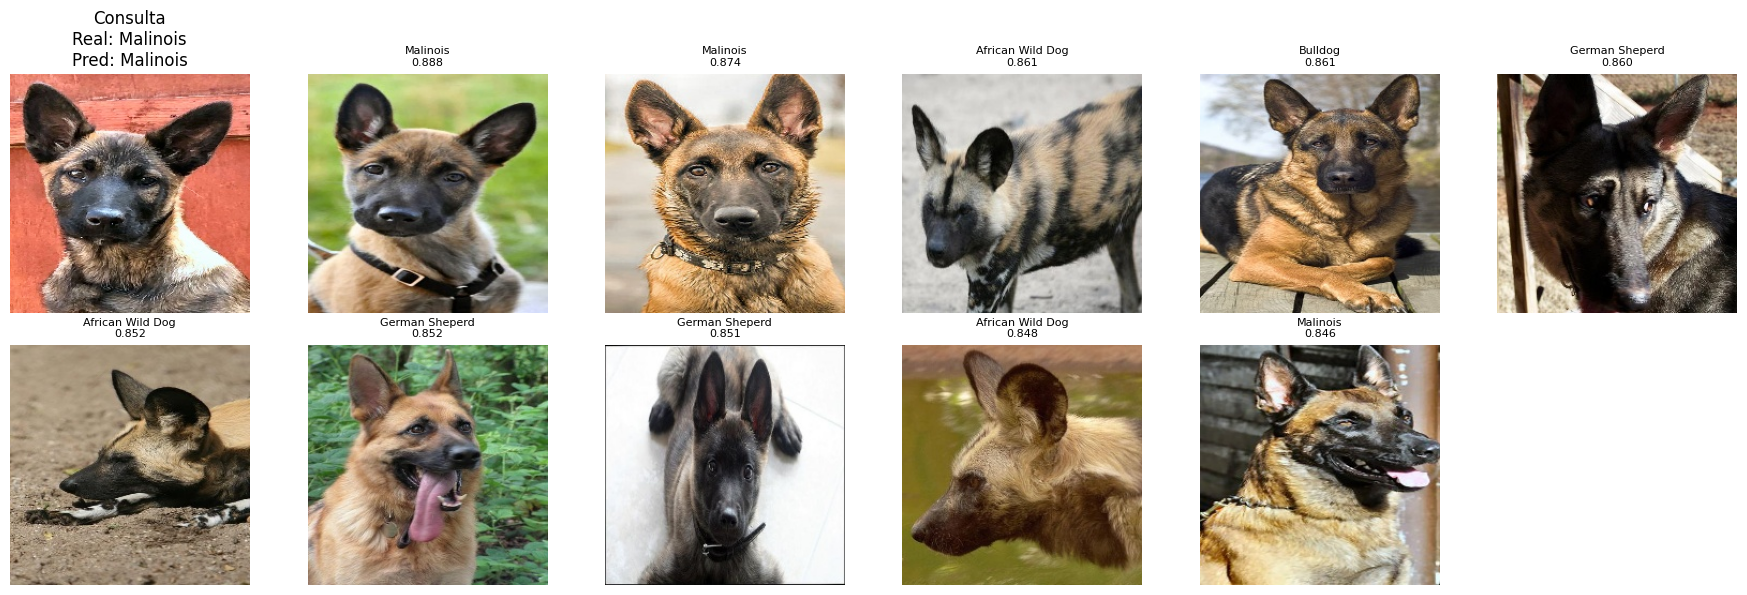

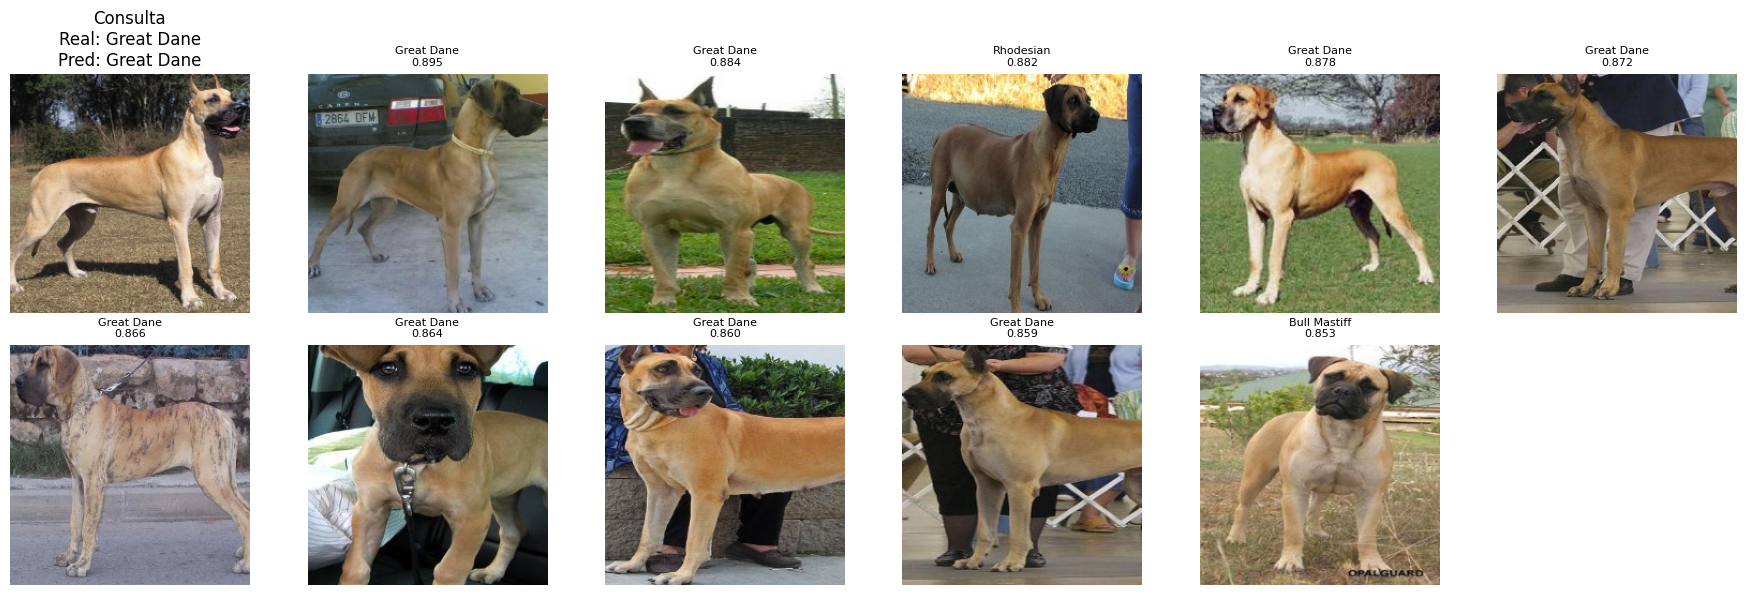

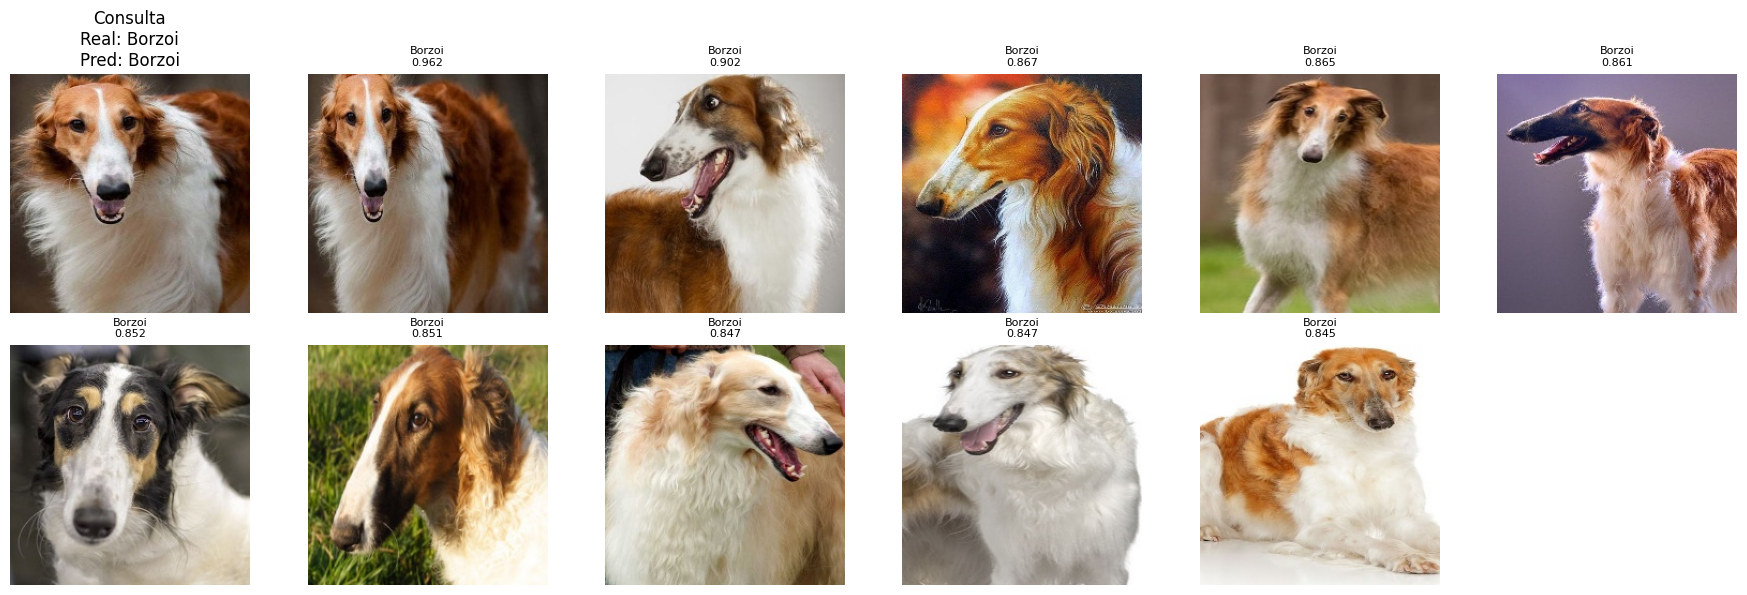

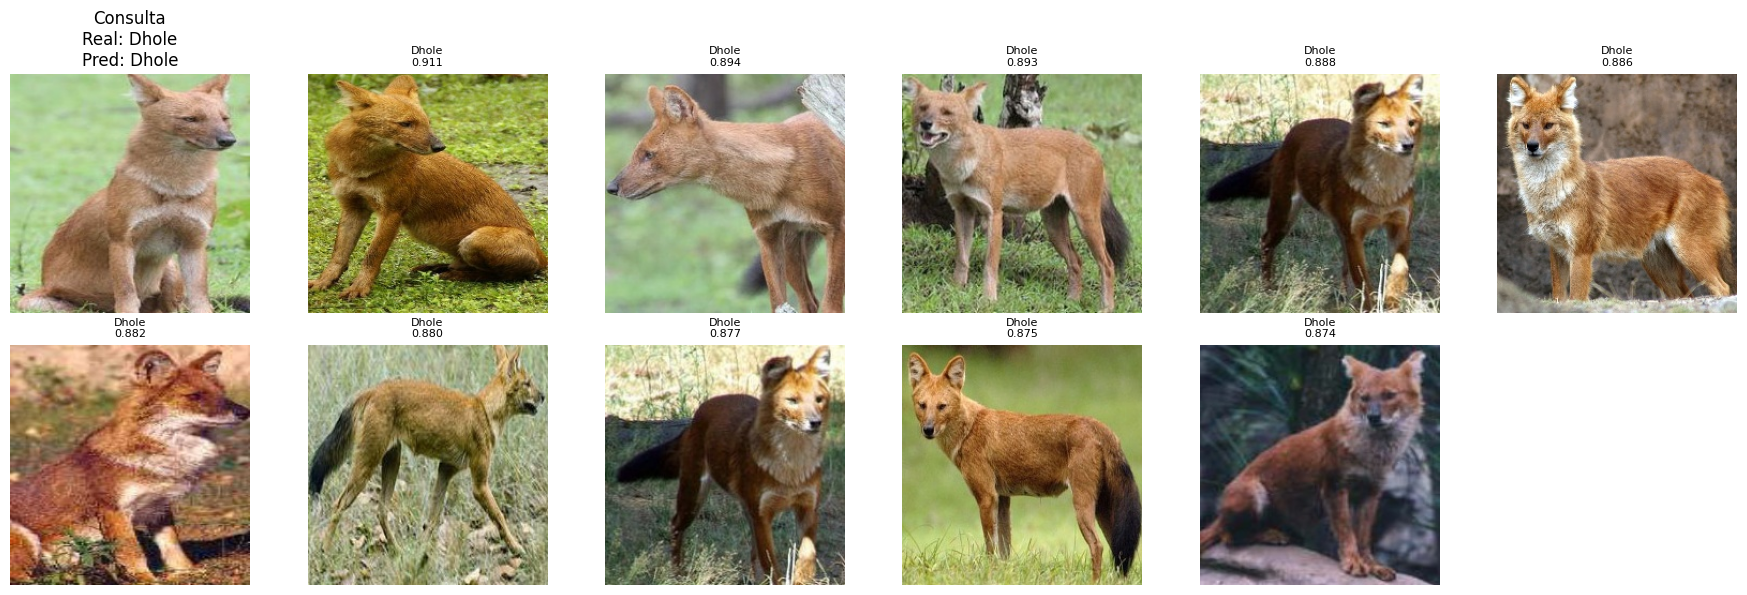

In [ ]:
import random

random.seed(42)

sample_test = test.sample(n=5, random_state=42)

import matplotlib.pyplot as plt
import cv2

def mostrar_resultados(row):

    image_path = os.path.join(BASE_PATH, row["filepaths"])

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    embedding = extract_embedding(image[:, :, ::-1])  # vuelve a BGR para mantener tu función

    neighbors = search_similar_images(
        embedding,
        database,
        top_k=10
    )

    pred, score = predict_breed_from_neighbors(neighbors)

    fig = plt.figure(figsize=(18,6))

    ax = fig.add_subplot(2,6,1)
    ax.imshow(image)
    ax.set_title(f"Consulta\nReal: {row['labels']}\nPred: {pred}")
    ax.axis("off")

    for i, neighbor in enumerate(neighbors):

        img = cv2.imread(neighbor["path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = fig.add_subplot(2,6,i+2)
        ax.imshow(img)
        ax.set_title(
            f"{neighbor['breed']}\n{neighbor['score']:.3f}",
            fontsize=8
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()

for _, row in sample_test.iterrows():
    mostrar_resultados(row)